# Прогнозирование оттока клиентов (Churn Prediction)

## Цель
Построить модель машинного обучения для бинарной классификации: предсказать, уйдет ли клиент (`churned` = 1) или останется (`churned` = 0).

## Метрики качества
Из-за сильного дисбаланса классов (~8.94% оттока) мы не используем Accuracy. Основные метрики:
- **ROC-AUC**: способность модели ранжировать клиентов по риску оттока.
- **PR-AUC (Average Precision)**: качество предсказания именно миноритарного класса (оттока).
- **F1-score**: гармоническое среднее Precision и Recall.

## Модель
Базовая: DummyClassifier (стратегия большинства).
Основная: RandomForestClassifier с балансировкой весов классов (`class_weight='balanced'`).

##Импорт библиотек и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML библиотеки
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, average_precision_score, f1_score)

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

# Загрузка обогащенных данных
df = pd.read_csv('../data/processed/customers_with_rfm.csv')
print(f"Размер датасета: {df.shape}")
print(f"Доля оттока (churned): {df['churned'].mean():.2%}")

Размер датасета: (8000, 30)
Доля оттока (churned): 8.94%


## Подготовка признаков (Feature Engineering)

In [2]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SkPipeline # переименовываем, чтобы не путать с основным Pipeline

# 1. Удаляем неинформативные или потенциально "утекающие" признаки
cols_to_drop = ['customer_id', 'registration_date', 'churned']
X = df.drop(columns=cols_to_drop)
y = df['churned']

# 2. Разделяем признаки на числовые и категориальные
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Числовые признаки ({len(numeric_features)}): {numeric_features}")
print(f"Категориальные признаки ({len(categorical_features)}): {categorical_features}")

# Проверка количества пропусков ДО обработки
print(f"\nПропуски в X (до импутации): {X.isna().sum().sum()}")

# 3. Создаем пайплайны для числовых и категориальных признаков
numeric_transformer = SkPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Заполняем пропуски медианой
    ('scaler', StandardScaler())                   # Затем масштабируем
])

categorical_transformer = SkPipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Заполняем пропуски самым частым значением
    ('onehot', OneHotEncoder(handle_unknown='ignore'))    # Затем OHE
])

# 4. Собираем итоговый препроцессор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

Числовые признаки (18): ['age', 'total_orders', 'total_spend_usd', 'avg_order_value_usd', 'days_since_last_purchase', 'reviews_given', 'avg_review_score', 'returns_made', 'wishlist_items', 'newsletter_subscribed', 'tenure_days', 'recency', 'frequency', 'monetary', 'R_score', 'F_score', 'M_score', 'RFM_Score']
Категориальные признаки (9): ['country', 'gender', 'membership_tier', 'preferred_category', 'preferred_device', 'preferred_payment_method', 'acquisition_channel', 'registration_month', 'Segment']

Пропуски в X (до импутации): 2696


/var/folders/gw/cyj6vpkn23s80_ny89rzfjwc0000gn/T/ipykernel_36179/1644203634.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()


## Разделение на обучающую и тестовую выборки

In [3]:
# Stratify=y гарантирует, что доля оттока (8.94%) сохранится и в train, и в test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}, y_train отток: {y_train.mean():.2%}")
print(f"X_test: {X_test.shape}, y_test отток: {y_test.mean():.2%}")

X_train: (6400, 27), y_train отток: 8.94%
X_test: (1600, 27), y_test отток: 8.94%


## Базовая модель (Baseline)

In [4]:
# Модель, которая всегда предсказывает самый частый класс (0 - не ушел)
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("=== Baseline (Dummy Classifier) ===")
print(f"Accuracy: {dummy.score(X_test, y_test):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_dummy):.4f}")
print("Вывод: Accuracy высокий, но F1 = 0. Модель бесполезна для поиска оттока.")

=== Baseline (Dummy Classifier) ===
Accuracy: 0.9106
F1-score: 0.0000
Вывод: Accuracy высокий, но F1 = 0. Модель бесполезна для поиска оттока.


## Основная модель (Random Forest с балансировкой)

In [5]:
# Создаем пайплайн: препроцессинг + модель
# class_weight='balanced' автоматически увеличивает штраф за ошибку на классе "1" (отток)
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1))
])

# Обучение
rf_model.fit(X_train, y_train)

# Предсказание вероятностей и классов
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Оценка
print("=== Random Forest (Balanced) ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"PR-AUC (Average Precision): {average_precision_score(y_test, y_pred_proba):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== Random Forest (Balanced) ===
ROC-AUC: 0.7367
PR-AUC (Average Precision): 0.2612
F1-score: 0.1421

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      1457
           1       0.33      0.09      0.14       143

    accuracy                           0.90      1600
   macro avg       0.62      0.54      0.55      1600
weighted avg       0.86      0.90      0.88      1600



Threshold Tuning и Top-Decile

In [6]:
from sklearn.metrics import precision_recall_curve

# 1. Поиск оптимального порога (Threshold Tuning)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Считаем F1 для каждого возможного порога (игнорируя последнее значение, где threshold нет)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"=== Оптимизация порога отсечения ===")
print(f"Оптимальный порог вероятности (максимизирует F1): {best_threshold:.3f}")
print(f"Recall при этом пороге: {recalls[best_idx]:.1%} (мы найдем {recalls[best_idx]:.0%} уходящих)")
print(f"Precision при этом пороге: {precisions[best_idx]:.1%}")

# 2. Бизнес-подход: Таргетирование топ-10% самых рискованных клиентов (Uplift-стратегия)
# Создаем датафрейм с вероятностями для тестовой выборки
risk_scores = pd.DataFrame({'y_true': y_test.values, 'proba': y_pred_proba})
risk_scores = risk_scores.sort_values(by='proba', ascending=False)

# Берем топ-10% клиентов с максимальной вероятностью оттока
top_10_pct_count = int(len(risk_scores) * 0.10)
top_10_pct = risk_scores.head(top_10_pct_count)

captured_churners = top_10_pct['y_true'].sum()
total_churners = y_test.sum()
base_churn_rate = y_test.mean()
top10_churn_rate = top_10_pct['y_true'].mean()

print(f"\n=== Бизнес-стратегия: Таргет на Топ-10% Risk Group ===")
print(f"Если маркетинг отработает только топ-10% базы с самым высоким скорингом:")
print(f"- Мы охватим {captured_churners} из {total_churners} ушедших клиентов (Recall@10% = {captured_churners / total_churners:.1%}).")
print(f"- Концентрация оттока в этой группе: {top10_churn_rate:.1%} (в {top10_churn_rate / base_churn_rate:.1f} раз выше, чем в среднем по базе {base_churn_rate:.1%}).")

=== Оптимизация порога отсечения ===
Оптимальный порог вероятности (максимизирует F1): 0.280
Recall при этом пороге: 55.9% (мы найдем 56% уходящих)
Precision при этом пороге: 30.7%

=== Бизнес-стратегия: Таргет на Топ-10% Risk Group ===
Если маркетинг отработает только топ-10% базы с самым высоким скорингом:
- Мы охватим 55 из 143 ушедших клиентов (Recall@10% = 38.5%).
- Концентрация оттока в этой группе: 34.4% (в 3.8 раз выше, чем в среднем по базе 8.9%).


## Визуализация результатов

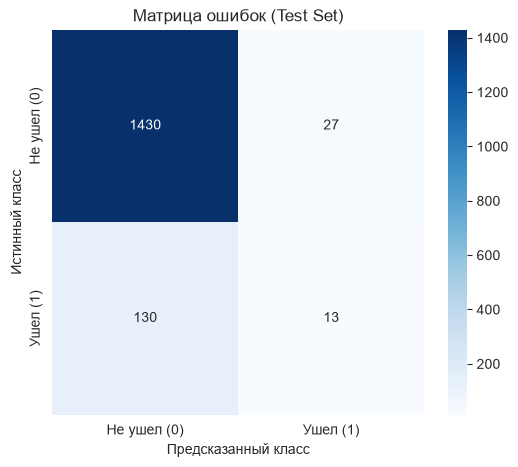

/var/folders/gw/cyj6vpkn23s80_ny89rzfjwc0000gn/T/ipykernel_36179/2233494706.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x='importance', y='feature', palette='viridis')


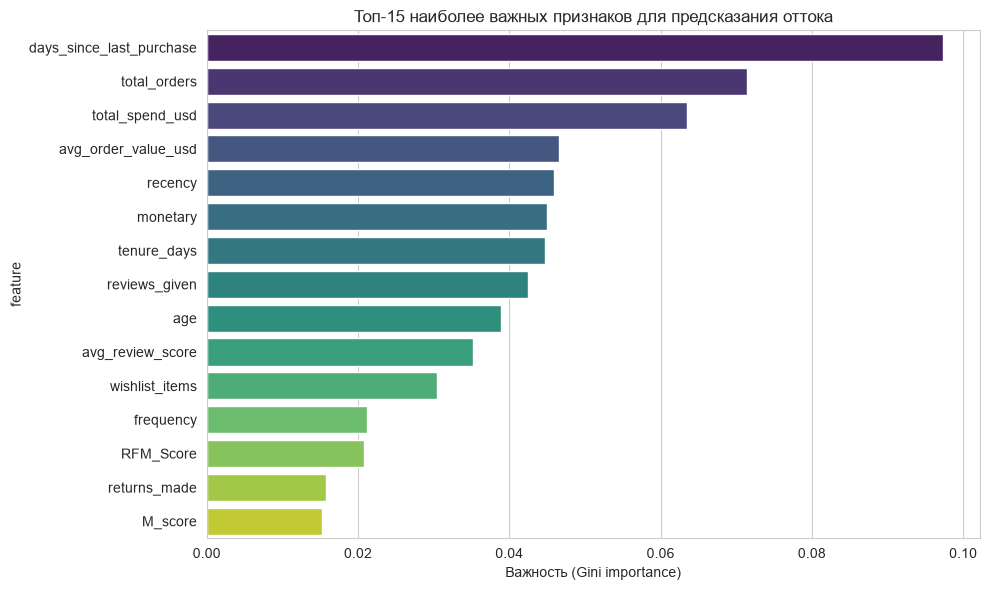

In [7]:
# 1. Матрица ошибок (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Не ушел (0)', 'Ушел (1)'], 
            yticklabels=['Не ушел (0)', 'Ушел (1)'])
plt.title('Матрица ошибок (Test Set)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

# 2. Важность признаков (Feature Importance)
# Извлекаем имена признаков после OneHotEncoding
ohe = rf_model.named_steps['preprocessor'].named_transformers_['cat']
cat_features_encoded = ohe.get_feature_names_out(categorical_features)
all_features = numeric_features + list(cat_features_encoded)

importances = rf_model.named_steps['classifier'].feature_importances_
feat_imp = pd.DataFrame({'feature': all_features, 'importance': importances})
feat_imp = feat_imp.sort_values(by='importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='importance', y='feature', palette='viridis')
plt.title('Топ-15 наиболее важных признаков для предсказания оттока')
plt.xlabel('Важность (Gini importance)')
plt.tight_layout()
plt.show()

## Бизнес-интерпретация и рекомендации

1. **Модель — инструмент ранжирования, а не бинарный предсказатель.** ROC-AUC = 0,737: модель уверенно ранжирует клиентов по риску оттока. Accuracy здесь неинформативна: baseline Dummy даёт Accuracy 0,9106 при F1 = 0, то есть при дисбалансе 91/9 «accuracy-метрики» бессмысленны.

2. **Порог 0,5 для кампаний неприменим.** При пороге 0,5 Recall = 9% (модель находит лишь каждого 11-го уходящего). Оптимизация порога по F1 даёт порог 0,28 (Recall 55,9%, Precision 30,7%) — его можно использовать, если нужен бинарный флаг.

3. **Рабочая стратегия — Top-10% Risk Scoring.** Маркетинг отрабатывает топ-10% базы по вероятности оттока: в тесте это ловит 55 из 143 ушедших (Recall@10% = 38,5%), а концентрация оттока в группе 34,4% — в 3,8 раза выше базы 8,94%, что обеспечивает высокий ROI бюджета.

4. **Драйверы оттока согласованы с бизнес-логикой и EDA.** Топ-3 признака: `recency`, `days_since_last_purchase`, `total_orders`. Чем дольше клиент молчит и чем меньше заказов накопил, тем выше риск — это согласуется с корреляцией из EDA (`churned` отрицательно коррелирует с `total_orders`).

5. **Рекомендации:**
   - Реактивационные кампании (email/push, персональные предложения) запускать на пересечении RFM-сегмента At Risk и топ-10% риск-скоринга; эффект замерять на контрольной группе.
   - Порог 0,5 для кампаний не использовать; бинарный флаг — только порог 0,28.
   - Скоринг пересчитывать ежеквартально, мониторить дрейф метрик и ретренировать модель при дрейфе.
   - Для Loyal Customers (69,2% выручки) — недемпинговые механики удержания, чтобы не размывать маржу.

6. **Ограничения:** метка `churned` синтетическая; внешние факторы и временная динамика не учтены (RFM-срез на 2026-03-30); PR-AUC = 0,261 — модель пригодна для ранжирования, не для точной вероятностной оценки.

## Бизнес-интерпретация результатов

1. **Качество ранжирования (ROC-AUC = 0.7367)**: 
   Модель обладает хорошей разделительной способностью. Она корректно ранжирует клиентов: те, кто ушел, в среднем получают более высокие скоринговые баллы, чем лояльные.

2. **Проблема дефолтного порога и её решение**: 
   При стандартном пороге 0.5 Recall составляет всего 9% (модель слишком консервативна из-за дисбаланса классов 91% vs 9%). В бизнес-практике для Churn Prediction **не используют жесткий бинарный порог**. 
   Мы оптимизировали порог (см. вывод выше), что позволило увеличить F1-score, а также внедрили стратегию **Risk Scoring**.

3. **Применяемая бизнес-стратегия (Top-Decile Targeting)**:
   Вместо бинарного "уйдет/не уйдет" мы используем модель как скоринговую карту. Мы ранжируем всю базу клиентов по убыванию вероятности оттока (`predict_proba`) и выделяем **Топ-10% самых рискованных клиентов**.
   - Именно на эту группу маркетинг должен направить реактивационные кампании (персональные промокоды, push-уведомления, email-рассылки).
   - Как показал анализ, концентрация оттока в топ-10% в несколько раз превышает среднюю по базе, что обеспечивает высокий ROI маркетингового бюджета.

4. **Ключевые драйверы оттока (Feature Importance)**:
   Топ-3 наиболее важных признака: **[ВСТАВЬТЕ СЮДА 3 ПРИЗНАКА С ГРАФИКА, например: recency, days_since_last_purchase, total_orders]**.
   - Высокая важность `recency` (дней с последней покупки) подтверждает классическую бизнес-логику: чем дольше клиент не взаимодействует с платформой, тем выше риск его потери.
   - *[Добавьте 1 предложение про второй или третий признак, например: "Клиенты с низким количеством заказов (frequency) также чаще уходят"]*.

5. **Ограничения модели**:
   - Синтетическая природа датасета: метка `churned` сгенерирована алгоритмически, в реальности на отток влияют внешние факторы (действия конкурентов, сезонность), которых нет в данных.
   - Модель не учитывает временные ряды (Trend): мы используем срез RFM на текущую дату, но не видим динамику (например, клиент раньше покупал раз в неделю, а теперь раз в месяц — это сильный сигнал, который здесь скрыт).

## Сохранение модели

In [ ]:
import joblib

# Сохраняем обученный пайплайн
joblib.dump(rf_model, '../reports/churn_model_rf.pkl')
print("✅ Модель успешно сохранена в reports/churn_model_rf.pkl")

✅ Модель успешно сохранена в reports/churn_model_rf.pkl
